# 26 — Sign of the hard-set errors, and a spread sweep against rho-shrinkage

**Read-only. No training, no Chemprop, no torch, no model, no submission, no corpus
retrieval, no change to `src/calibration.py`.**

## Motivation

Notebook 25 found the consensus-hard compounds are structurally ORDINARY relative to
training on every isoform (NN-similarity rank-biserial r 0.02-0.09, none surviving BH
correction), closing the retrieved-neighbour-corpus route. What DOES characterise the
hard sets on CYP2C9/CYP2D6/CYP3A4 is higher measured pIC50, narrower credible
intervals, higher lipophilicity and lower FractionCSP3. CYP1A2's hard set is
genuinely diffuse.

The hard compounds being systematically more potent has an obvious, never-checked
candidate mechanism: a model whose predictions are compressed toward the mean will
under-predict the potent tail hardest. Two independent prior observations are
consistent with it — notebook 21's under-prediction/over-prediction error ratio of
1.65-2.79x, and notebook 10b's finding that every submitted prediction distribution's
std sits below the training-label std on every isoform. This notebook tests the
mechanism directly (Part 1: is the hard set's error actually signed negative?) and
then asks a question no prior notebook has: is the SPREAD multiplier this project's
own deployed calibration applies (governed by `rho`) actually ST-RAE-optimal, or just
squared-error-optimal (Part 2)? Part 3 repeats the CYP2D6 half of Part 2 against the
solved blind population instead of OOF truth, carrying notebook 21's own
population-mismatch caveat forward explicitly.

## Scope boundaries (repeated here so they're visible in the executed notebook)
- No training, no Chemprop, no torch, no model of any kind is fit here.
- Read-only on `outputs/11_caruana_prep/`, `outputs/25_hard_compound_analysis/`,
  `outputs/21_strae_offset_curve/`, `outputs/calibration_blind_population/`,
  `outputs/population_moments/`, `outputs/board_solved_calibration/`,
  `outputs/19_cyp2c9_revert/`, `data/`, `src/`, and every submission artifact.
- ST-RAE is used only via the vendored evaluator, never reimplemented.
- No submission built, validated, or sent. No adoption recommended.

## User-confirmed decision before building Part 3

Part 3 evaluates the corrected CYP2D6 blind column against synthetic draws from a
modelled population with no credible-interval bounds available. Asked and confirmed
with the user before writing that section: compute **plain RAE via the same vendored
function with no bounds supplied** — `rae_soft_threshold_absolute_error`'s own
docstring confirms omitting both bounds collapses the tolerance band to a single
point, making its result identical to plain RAE. This reuses the exact same vendored,
unmodified function; it introduces no invented interval width and no new metric.


In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import importlib.metadata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import fisher_exact, mannwhitneyu, spearmanr
from sklearn.metrics import r2_score
from statsmodels.stats.multitest import multipletests

from src.vendor.openadmet_eval.config import REGRESSION_ENDPOINTS
from src.vendor.openadmet_eval.custom_scoring_functions import rae_soft_threshold_absolute_error

print(f"python: {sys.version.split()[0]}")
for pkg in ["numpy", "pandas", "scipy", "scikit-learn", "matplotlib", "statsmodels"]:
    print(f"{pkg}: {importlib.metadata.version(pkg)}")

ISOFORMS = [e.split("_")[0] for e in REGRESSION_ENDPOINTS]
PIC50_COL = {iso: f"{iso}_pIC50_direct_inhibition" for iso in ISOFORMS}
ALPHA = 0.05

OUT11PREP = REPO_ROOT / "outputs" / "11_caruana_prep"
OUT25 = REPO_ROOT / "outputs" / "25_hard_compound_analysis"
OUT21 = REPO_ROOT / "outputs" / "21_strae_offset_curve"
OUTCAL = REPO_ROOT / "outputs" / "calibration_blind_population"
OUTPOP = REPO_ROOT / "outputs" / "population_moments"
OUTBOARD = REPO_ROOT / "outputs" / "board_solved_calibration"
OUT = REPO_ROOT / "outputs" / "26_spread_sweep"
FIG_OUT = OUT / "figures"
FIG_OUT.mkdir(parents=True, exist_ok=True)

print(f"\nisoforms: {ISOFORMS}")


python: 3.11.13
numpy: 1.26.4
pandas: 2.3.3
scipy: 1.17.1
scikit-learn: 1.9.0
matplotlib: 3.11.1
statsmodels: 0.14.6

isoforms: ['CYP1A2', 'CYP2C9', 'CYP2D6', 'CYP3A4']


## Part 1 — Sign of the errors on the hard set

### Rebuild the signed-error table, reusing notebook 25's own repeat-averaging convention

Notebook 25 froze this convention (its cell building `compound_config_tables`):
signed error is `prediction - y_true` per row, averaged over a compound's 5 repeats
**per config**, matching that notebook's own code exactly
(`err = df[CONFIG_COLS].sub(df["y_true"], axis=0)`, then
`err.groupby("inchikey")[CONFIG_COLS].mean()`). Reused verbatim below rather than
re-derived from description. The compound-level **mean absolute error across the 11
configs** this produces is verified against notebook 25's own saved
`hard_compound_table.csv` (tolerance `< 1e-8`) before anything else is trusted — this
is the "verify against notebook 25's own cells rather than assuming" check the task
requires. The **signed** mean across configs (needed for this notebook, not saved by
notebook 25, which only kept the absolute value) is computed the same way.


In [2]:
oof_tables = {}
CONFIG_COLS = None
for iso in ISOFORMS:
    df = pd.read_csv(OUT11PREP / f"oof_long_{iso}.csv")
    oof_tables[iso] = df
    cfg_cols = [c for c in df.columns
                if c not in ("repeat", "fold", "inchikey", "Molecule_Name", "y_true", "conf_low", "conf_high")]
    if CONFIG_COLS is None:
        CONFIG_COLS = cfg_cols
    else:
        assert cfg_cols == CONFIG_COLS, f"{iso}: config columns differ from {ISOFORMS[0]}"
print(f"config columns ({len(CONFIG_COLS)}): {CONFIG_COLS}")

nb25_table = pd.read_csv(OUT25 / "hard_compound_table.csv")
print(f"notebook 25's hard_compound_table.csv: {nb25_table.shape}")

signed_error_tables = {}
for iso in ISOFORMS:
    df = oof_tables[iso]
    # notebook 25's own convention, reused verbatim: signed error per row, then mean over the
    # 5 repeats per (compound, config).
    err = df[CONFIG_COLS].sub(df["y_true"], axis=0)
    err["inchikey"] = df["inchikey"].to_numpy()
    mean_err_by_config = err.groupby("inchikey")[CONFIG_COLS].mean()

    mean_abs_error = mean_err_by_config.abs().mean(axis=1)   # notebook 25's own quantity -- verified below
    mean_signed_error = mean_err_by_config.mean(axis=1)       # this notebook's quantity -- not saved by notebook 25

    nb25_sub = nb25_table[nb25_table["isoform"] == iso].set_index("inchikey")
    nb25_sub = nb25_sub.loc[mean_abs_error.index]
    max_diff = (mean_abs_error - nb25_sub["mean_abs_error"]).abs().max()
    assert max_diff < 1e-8, f"{iso}: rebuilt mean_abs_error disagrees with notebook 25's own saved value by {max_diff}"

    table = pd.DataFrame({
        "y_true": nb25_sub["y_true"], "mean_signed_error": mean_signed_error,
        "mean_abs_error": mean_abs_error, "hard_soft": nb25_sub["hard_soft"], "easy_soft": nb25_sub["easy_soft"],
    })
    signed_error_tables[iso] = table
    print(f"{iso}: rebuilt signed-error table for {len(table)} compounds -- "
          f"verified against notebook 25's own mean_abs_error, max abs diff={max_diff:.2e}")

print("\nVERIFIED: this notebook's repeat-averaging reproduces notebook 25's own saved values exactly, "
      "confirming the convention is reused correctly, not assumed.")


config columns (11): ['chemeleon__lightgbm', 'chemeleon__rf', 'chemeleon__xgboost', 'chemprop_chemeleoninit', 'chemprop_randominit', 'ecfp4_narrow__lightgbm', 'ecfp4_narrow__rf', 'ecfp4_narrow__xgboost', 'mordred_pca__lightgbm', 'mordred_pca__rf', 'mordred_pca__xgboost']
notebook 25's hard_compound_table.csv: (6525, 25)
CYP1A2: rebuilt signed-error table for 1412 compounds -- verified against notebook 25's own mean_abs_error, max abs diff=4.44e-16
CYP2C9: rebuilt signed-error table for 1285 compounds -- verified against notebook 25's own mean_abs_error, max abs diff=2.22e-16
CYP2D6: rebuilt signed-error table for 1493 compounds -- verified against notebook 25's own mean_abs_error, max abs diff=4.44e-16
CYP3A4: rebuilt signed-error table for 2335 compounds -- verified against notebook 25's own mean_abs_error, max abs diff=4.44e-16

VERIFIED: this notebook's repeat-averaging reproduces notebook 25's own saved values exactly, confirming the convention is reused correctly, not assumed.


### Sign of the errors: hard vs. easy vs. all

Two complementary tests per isoform, both on the SOFT-THRESHOLD hard/easy definition
(notebook 25's primary definition, since that notebook found the plain-AE and
soft-threshold hard sets differ materially — Jaccard 0.06-0.48): (1) a **sign** test
(negative vs. non-negative signed error), 2x2 Fisher's exact, hard vs. easy, odds
ratio as effect size; (2) a **continuous** Mann-Whitney U test on the signed error
itself with rank-biserial r, matching notebook 25's own precedent for hard-vs-easy
comparisons. Both test families (4 isoforms each) get their own Benjamini-Hochberg
correction, matching this project's established convention of correcting within a
family of like comparisons across isoforms (notebook 25 Part 3's cross-isoform-pair
family is the direct precedent for this structure).


In [3]:
sign_rows = []
for iso in ISOFORMS:
    t = signed_error_tables[iso]
    hard = t[t["hard_soft"]]
    easy = t[t["easy_soft"]]
    all_c = t

    for label, sub in [("consensus_hard", hard), ("consensus_easy", easy), ("all", all_c)]:
        sign_rows.append({
            "isoform": iso, "group": label, "n": len(sub),
            "mean_signed_error": sub["mean_signed_error"].mean(),
            "median_signed_error": sub["mean_signed_error"].median(),
            "frac_negative": float((sub["mean_signed_error"] < 0).mean()),
        })

sign_summary = pd.DataFrame(sign_rows)
sign_summary.to_csv(OUT / "sign_summary.csv", index=False)
print(sign_summary.round(4).to_string(index=False))


isoform          group    n  mean_signed_error  median_signed_error  frac_negative
 CYP1A2 consensus_hard  142            -0.1298              -1.2382         0.6408
 CYP1A2 consensus_easy  142             0.0483               0.0311         0.4085
 CYP1A2            all 1412            -0.0018              -0.1184         0.5864
 CYP2C9 consensus_hard  129            -0.7190              -0.9657         0.8605
 CYP2C9 consensus_easy  129             0.0956               0.0892         0.2481
 CYP2C9            all 1285             0.0006              -0.0233         0.5230
 CYP2D6 consensus_hard  150            -0.6087              -1.3051         0.7667
 CYP2D6 consensus_easy  150             0.0186               0.0209         0.4467
 CYP2D6            all 1493            -0.0085              -0.0031         0.5030
 CYP3A4 consensus_hard  234            -0.9633              -1.1085         0.9274
 CYP3A4 consensus_easy  234             0.3288               0.3272         0.1966
 CYP

In [4]:
sign_test_rows = []
for iso in ISOFORMS:
    t = signed_error_tables[iso]
    hard = t[t["hard_soft"]]
    easy = t[t["easy_soft"]]

    hard_neg = int((hard["mean_signed_error"] < 0).sum())
    easy_neg = int((easy["mean_signed_error"] < 0).sum())
    table_2x2 = [[hard_neg, len(hard) - hard_neg], [easy_neg, len(easy) - easy_neg]]
    odds_ratio, p_fisher = fisher_exact(table_2x2)

    u_stat, p_mw = mannwhitneyu(hard["mean_signed_error"], easy["mean_signed_error"], alternative="two-sided")
    r_biserial = 1 - (2 * u_stat) / (len(hard) * len(easy))

    sign_test_rows.append({
        "isoform": iso, "n_hard": len(hard), "n_easy": len(easy),
        "frac_negative_hard": hard_neg / len(hard), "frac_negative_easy": easy_neg / len(easy),
        "odds_ratio": odds_ratio, "p_fisher_raw": p_fisher,
        "rank_biserial_r": r_biserial, "p_mannwhitney_raw": p_mw,
    })

sign_tests = pd.DataFrame(sign_test_rows)
_, p_fisher_adj, _, _ = multipletests(sign_tests["p_fisher_raw"].to_numpy(), method="fdr_bh")
_, p_mw_adj, _, _ = multipletests(sign_tests["p_mannwhitney_raw"].to_numpy(), method="fdr_bh")
sign_tests["p_fisher_adj"] = p_fisher_adj
sign_tests["p_mannwhitney_adj"] = p_mw_adj
sign_tests["fisher_significant"] = sign_tests["p_fisher_adj"] < ALPHA
sign_tests["mannwhitney_significant"] = sign_tests["p_mannwhitney_adj"] < ALPHA
sign_tests.to_csv(OUT / "sign_tests.csv", index=False)
print(sign_tests.round(4).to_string(index=False))


isoform  n_hard  n_easy  frac_negative_hard  frac_negative_easy  odds_ratio  p_fisher_raw  rank_biserial_r  p_mannwhitney_raw  p_fisher_adj  p_mannwhitney_adj  fisher_significant  mannwhitney_significant
 CYP1A2     142     142              0.6408              0.4085      2.5842        0.0001           0.2817                0.0        0.0001                0.0                True                     True
 CYP2C9     129     129              0.8605              0.2481     18.6927        0.0000           0.7209                0.0        0.0000                0.0                True                     True
 CYP2D6     150     150              0.7667              0.4467      4.0704        0.0000           0.5333                0.0        0.0000                0.0                True                     True
 CYP3A4     234     234              0.9274              0.1966     52.1688        0.0000           0.8547                0.0        0.0000                0.0                True      

### Signed error by potency decile

All compounds (not just hard/easy) binned into deciles by measured pIC50, per
isoform. If spread compression is the mechanism, signed error should trend from
positive at low pIC50 (over-prediction of weak compounds, pulled up toward the mean)
to negative at high pIC50 (under-prediction of potent compounds, pulled down toward
the mean), crossing zero near the training mean.


In [5]:
N_DECILES = 10
decile_rows = []
for iso in ISOFORMS:
    t = signed_error_tables[iso]
    deciles = pd.qcut(t["y_true"], N_DECILES, labels=False, duplicates="drop")
    training_mean = t["y_true"].mean()

    for d in sorted(deciles.dropna().unique()):
        mask = deciles == d
        decile_rows.append({
            "isoform": iso, "decile": int(d),
            "pic50_low": t.loc[mask, "y_true"].min(), "pic50_high": t.loc[mask, "y_true"].max(),
            "n": int(mask.sum()), "mean_signed_error": t.loc[mask, "mean_signed_error"].mean(),
            "training_mean_pic50": training_mean,
        })

decile_table = pd.DataFrame(decile_rows)
decile_table.to_csv(OUT / "signed_error_by_decile.csv", index=False)

for iso in ISOFORMS:
    sub = decile_table[decile_table["isoform"] == iso].sort_values("decile")
    signs = np.sign(sub["mean_signed_error"].to_numpy())
    # crossing count: how many times consecutive deciles' mean signed error changes sign
    n_crossings = int((np.diff(signs) != 0).sum())
    monotonic_trend = bool(sub["mean_signed_error"].is_monotonic_decreasing)
    print(f"{iso}: decile-0 (lowest pIC50) mean signed error={sub.iloc[0]['mean_signed_error']:+.4f}, "
          f"decile-{int(sub.iloc[-1]['decile'])} (highest pIC50) mean signed error={sub.iloc[-1]['mean_signed_error']:+.4f}, "
          f"sign crossings={n_crossings}, strictly monotonic decreasing={monotonic_trend}")


CYP1A2: decile-0 (lowest pIC50) mean signed error=+1.8781, decile-9 (highest pIC50) mean signed error=-1.3074, sign crossings=1, strictly monotonic decreasing=True
CYP2C9: decile-0 (lowest pIC50) mean signed error=+1.0855, decile-9 (highest pIC50) mean signed error=-0.9846, sign crossings=1, strictly monotonic decreasing=True
CYP2D6: decile-0 (lowest pIC50) mean signed error=+1.7034, decile-9 (highest pIC50) mean signed error=-1.3679, sign crossings=1, strictly monotonic decreasing=True
CYP3A4: decile-0 (lowest pIC50) mean signed error=+1.1078, decile-9 (highest pIC50) mean signed error=-0.9461, sign crossings=1, strictly monotonic decreasing=True


### Part 1 verdict, per isoform

**Decision rule, stated before reading the numbers below into a verdict**: a hard set
is called "systematically under-predicted" only if ALL THREE hold: (a) its median
signed error is more negative than -0.05 pIC50 (a small but non-trivial magnitude —
near-zero medians are not "systematic"), (b) its fraction with negative signed error
exceeds 0.6 (materially more than half), and (c) the Fisher sign test against the easy
set is BH-significant. Falling short of any one of these is reported as "NOT
systematically under-predicted", not rounded up.


In [6]:
print("=" * 78)
print("PART 1 VERDICT -- per isoform, not averaged")
print("=" * 78)
for iso in ISOFORMS:
    hard_row = sign_summary[(sign_summary["isoform"] == iso) & (sign_summary["group"] == "consensus_hard")].iloc[0]
    test_row = sign_tests[sign_tests["isoform"] == iso].iloc[0]
    sub = decile_table[decile_table["isoform"] == iso].sort_values("decile")

    under_predicted = (
        hard_row["median_signed_error"] < -0.05
        and hard_row["frac_negative"] > 0.6
        and bool(test_row["fisher_significant"])
    )
    print(f"\n{iso}:")
    print(f"  hard-set median signed error={hard_row['median_signed_error']:+.4f}, "
          f"mean={hard_row['mean_signed_error']:+.4f}, frac_negative={hard_row['frac_negative']:.3f}")
    print(f"  vs. easy-set frac_negative={test_row['frac_negative_easy']:.3f}, "
          f"odds_ratio={test_row['odds_ratio']:.2f}, BH-adj p (Fisher)={test_row['p_fisher_adj']:.2e}, "
          f"BH-adj p (Mann-Whitney)={test_row['p_mannwhitney_adj']:.2e}")
    print(f"  decile trend: lowest-pIC50 decile mean signed error={sub.iloc[0]['mean_signed_error']:+.4f} "
          f"-> highest-pIC50 decile={sub.iloc[-1]['mean_signed_error']:+.4f}")

    if under_predicted:
        print("  VERDICT: hard set IS systematically UNDER-PREDICTED -- consistent with the "
              "spread-compression mechanism (a model compressed toward the mean under-predicts the potent tail).")
    else:
        print("  VERDICT: hard set is NOT systematically under-predicted by this notebook's stated rule -- "
              "the potency association found in notebook 25 needs a different or additional explanation "
              "for this isoform.")


PART 1 VERDICT -- per isoform, not averaged

CYP1A2:
  hard-set median signed error=-1.2382, mean=-0.1298, frac_negative=0.641
  vs. easy-set frac_negative=0.408, odds_ratio=2.58, BH-adj p (Fisher)=1.35e-04, BH-adj p (Mann-Whitney)=4.07e-05
  decile trend: lowest-pIC50 decile mean signed error=+1.8781 -> highest-pIC50 decile=-1.3074
  VERDICT: hard set IS systematically UNDER-PREDICTED -- consistent with the spread-compression mechanism (a model compressed toward the mean under-predicts the potent tail).

CYP2C9:
  hard-set median signed error=-0.9657, mean=-0.7190, frac_negative=0.860
  vs. easy-set frac_negative=0.248, odds_ratio=18.69, BH-adj p (Fisher)=7.25e-24, BH-adj p (Mann-Whitney)=2.80e-23
  decile trend: lowest-pIC50 decile mean signed error=+1.0855 -> highest-pIC50 decile=-0.9846
  VERDICT: hard set IS systematically UNDER-PREDICTED -- consistent with the spread-compression mechanism (a model compressed toward the mean under-predicts the potent tail).

CYP2D6:
  hard-set med

## Part 2 — The spread sweep

For each isoform independently, `chemprop_chemeleoninit`'s pooled OOF predictions
(the same `oof_long_{iso}.csv` files, already carrying their own `conf_low`/
`conf_high`, matching notebook 21's own data source) are transformed by a pure spread
scale holding the mean fixed:

```
pred_scaled = mean(pred) + s * (pred - mean(pred))
```

swept over `s` in [0.5, 3.0] step 0.01 as a minimum per the task brief, **extended
down to 0.2** once the first run showed why: CYP2D6's own `rho` (0.3685, read from
`calibration_blind_population/params.csv` below) sits below 0.5, which would have
made any "value at s=rho" comparison silently clamp to the s=0.5 grid edge instead of
actually evaluating at rho, and the ST-RAE optimum in the original [0.5, 3.0] range
turned out to sit exactly on that same lower boundary for CYP2D6 — a real signal that
the true unconstrained optimum might lie below 0.5, not an artifact to paper over
with a boundary value. The extended [0.2, 3.0] range (281 values, step 0.01) is used
throughout below, evaluated at every step through the vendored, unmodified
`rae_soft_threshold_absolute_error` (ST-RAE) and `r2_score` (R2) — mirroring notebook
21's own offset-sweep structure exactly, substituting a spread transform for an
additive one.


In [7]:
S_VALUES = np.round(np.linspace(0.2, 3.0, 281), 2)
assert len(S_VALUES) == 281
assert abs(S_VALUES[0] - 0.2) < 1e-8 and abs(S_VALUES[-1] - 3.0) < 1e-8
assert np.any(np.isclose(S_VALUES, 1.0)), "s=1.0 (raw, no transform) must be exactly on the swept grid"
assert np.any(np.isclose(S_VALUES, 0.5)), "s=0.5 (the task brief's own stated lower bound) must be exactly on the swept grid"

def spread_scale(pred, s):
    return np.mean(pred) + s * (pred - np.mean(pred))

spread_sweep_rows = []
for iso in ISOFORMS:
    df = oof_tables[iso]
    y_true = df["y_true"].to_numpy()
    pred_base = df["chemprop_chemeleoninit"].to_numpy()
    conf_low = df["conf_low"].to_numpy()
    conf_high = df["conf_high"].to_numpy()

    for s in S_VALUES:
        pred = spread_scale(pred_base, s)
        strae = rae_soft_threshold_absolute_error(y_true, pred, y_true_upper=conf_high, y_true_lower=conf_low)
        r2 = r2_score(y_true, pred)
        spread_sweep_rows.append({"isoform": iso, "s": float(s), "strae": strae, "r2": r2})

spread_sweep = pd.DataFrame(spread_sweep_rows)
spread_sweep.to_csv(OUT / "spread_sweep.csv", index=False)
print(f"saved {OUT / 'spread_sweep.csv'} ({len(spread_sweep)} rows)")
print(spread_sweep.groupby('isoform').size())


saved /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/26_spread_sweep/spread_sweep.csv (1124 rows)
isoform
CYP1A2    281
CYP2C9    281
CYP2D6    281
CYP3A4    281
dtype: int64


### Integrity check: Spearman must be invariant under a pure spread scale (s > 0)

Scaling every prediction by a positive constant around a fixed centre preserves
ordering exactly — Spearman is computed at three widely-separated values of `s` and
asserted not to move. If it moved, the bug would be in this notebook's pipeline, not
in the chemistry (matching notebook 21's own integrity-check pattern for its offset
sweep).


In [8]:
CHECK_S_VALUES = [0.2, 1.5, 3.0]
for iso in ISOFORMS:
    df = oof_tables[iso]
    y_true = df["y_true"].to_numpy()
    pred_base = df["chemprop_chemeleoninit"].to_numpy()
    rhos = [spearmanr(y_true, spread_scale(pred_base, s)).statistic for s in CHECK_S_VALUES]
    spread_of_rhos = max(rhos) - min(rhos)
    print(f"{iso}: Spearman at s={CHECK_S_VALUES} = {[round(r, 10) for r in rhos]}, spread={spread_of_rhos:.2e}")
    assert spread_of_rhos < 1e-8, f"{iso}: Spearman moved by {spread_of_rhos} across the spread sweep -- pipeline bug, stopping."

print("\nASSERTION PASSED: Spearman is invariant across the whole spread sweep, all four isoforms.")


CYP1A2: Spearman at s=[0.2, 1.5, 3.0] = [0.500478541, 0.500478541, 0.500478541], spread=0.00e+00
CYP2C9: Spearman at s=[0.2, 1.5, 3.0] = [0.6237001663, 0.6237001663, 0.6237001663], spread=0.00e+00
CYP2D6: Spearman at s=[0.2, 1.5, 3.0] = [0.390205602, 0.390205602, 0.390205602], spread=0.00e+00
CYP3A4: Spearman at s=[0.2, 1.5, 3.0] = [0.755992334, 0.755992334, 0.755992334], spread=0.00e+00

ASSERTION PASSED: Spearman is invariant across the whole spread sweep, all four isoforms.


### Per-isoform optima, and the gap to rho

`rho` is read directly from `outputs/calibration_blind_population/params.csv`'s own
`rho` column (Pearson correlation between OOF predictions and OOF true values, per
`src/calibration.py`'s `fit_blind_population_calibration` — confirmed by reading that
function's source, not assumed) and printed below before use, per the task's
verification requirement. **A real asymmetry, flagged rather than glossed over**:
that file's `model` column shows CYP1A2/CYP2D6/CYP3A4's `rho` was computed on
`chemprop_chemeleoninit` (the same model this notebook's spread sweep uses), but
CYP2C9's `rho` was computed on the `caruana_capped_ensemble` instead — the model
this project actually deployed for CYP2C9 (per notebook 19's revert history). The
`s = rho` comparison point for CYP2C9 is therefore comparing this notebook's
`chemprop_chemeleoninit` spread curve against a shrinkage factor estimated on a
*different* model's OOF correlation — reported as-is, flagged explicitly, not treated
as equivalent to the other three isoforms.


In [9]:
rho_table = pd.read_csv(OUTCAL / "params.csv")
print("outputs/calibration_blind_population/params.csv, read in full for verification:")
print(rho_table[["isoform", "model", "rho"]].to_string(index=False))

rho_by_isoform = rho_table.set_index("isoform")["rho"].to_dict()
rho_model_by_isoform = rho_table.set_index("isoform")["model"].to_dict()
for iso in ISOFORMS:
    flag = "" if rho_model_by_isoform[iso] == "chemprop_chemeleoninit" else "  <-- MODEL MISMATCH, flagged above"
    print(f"{iso}: rho={rho_by_isoform[iso]:.4f} (fit on {rho_model_by_isoform[iso]}){flag}")


outputs/calibration_blind_population/params.csv, read in full for verification:
isoform                   model      rho
 CYP1A2  chemprop_chemeleoninit 0.498868
 CYP2D6  chemprop_chemeleoninit 0.368531
 CYP3A4  chemprop_chemeleoninit 0.752331
 CYP2C9 caruana_capped_ensemble 0.653630
CYP1A2: rho=0.4989 (fit on chemprop_chemeleoninit)
CYP2C9: rho=0.6536 (fit on caruana_capped_ensemble)  <-- MODEL MISMATCH, flagged above
CYP2D6: rho=0.3685 (fit on chemprop_chemeleoninit)
CYP3A4: rho=0.7523 (fit on chemprop_chemeleoninit)


In [10]:
spread_optima_rows = []
for iso in ISOFORMS:
    sub = spread_sweep[spread_sweep["isoform"] == iso]
    strae_row = sub.loc[sub["strae"].idxmin()]
    r2_row = sub.loc[sub["r2"].idxmax()]
    raw_row = sub.loc[np.isclose(sub["s"], 1.0)].iloc[0]

    rho = rho_by_isoform[iso]
    s_grid = sub["s"].to_numpy()

    # rho must fall INSIDE the swept range for a comparison to mean anything -- np.interp
    # silently clamps to the edge value for an out-of-range x, which would misreport "ST-RAE at
    # rho" as the boundary value instead of raising. Checked explicitly rather than trusted.
    assert s_grid.min() <= rho <= s_grid.max(), (
        f"{iso}: rho={rho:.4f} falls outside the swept s range [{s_grid.min()}, {s_grid.max()}] -- "
        "extend the grid rather than silently clamping via interpolation."
    )
    strae_at_rho = float(np.interp(rho, s_grid, sub["strae"].to_numpy()))
    r2_at_rho = float(np.interp(rho, s_grid, sub["r2"].to_numpy()))

    gap_s = strae_row["s"] - rho
    gap_strae = strae_at_rho - strae_row["strae"]
    at_boundary = np.isclose(strae_row["s"], s_grid.min()) or np.isclose(strae_row["s"], s_grid.max())

    spread_optima_rows.append({
        "isoform": iso,
        "strae_optimal_s": strae_row["s"], "strae_at_optimum": strae_row["strae"],
        "r2_optimal_s": r2_row["s"], "r2_at_optimum": r2_row["r2"],
        "strae_at_s1": raw_row["strae"], "r2_at_s1": raw_row["r2"],
        "rho": rho, "strae_at_rho": strae_at_rho, "r2_at_rho": r2_at_rho,
        "gap_s_units_optimum_minus_rho": gap_s, "gap_strae_units_rho_minus_optimum": gap_strae,
        "rho_model": rho_model_by_isoform[iso], "strae_optimum_at_grid_boundary": bool(at_boundary),
    })
    print(f"\n{iso}:")
    print(f"  ST-RAE optimum: s={strae_row['s']:.2f}, ST-RAE={strae_row['strae']:.4f}"
          + ("  <-- AT GRID BOUNDARY: the true unconstrained optimum may lie beyond this range" if at_boundary else ""))
    print(f"  R2 optimum:     s={r2_row['s']:.2f}, R2={r2_row['r2']:.4f}")
    print(f"  raw (s=1.0):    ST-RAE={raw_row['strae']:.4f}, R2={raw_row['r2']:.4f}")
    print(f"  at s=rho={rho:.4f} ({rho_model_by_isoform[iso]}): ST-RAE={strae_at_rho:.4f}, R2={r2_at_rho:.4f}")
    print(f"  gap: ST-RAE optimum sits at s={strae_row['s']:.2f} vs. rho={rho:.4f} "
          f"({gap_s:+.2f} s-units {'above' if gap_s > 0 else 'below'} rho); "
          f"ST-RAE at rho minus ST-RAE at optimum = {gap_strae:+.4f}")

spread_optima_df = pd.DataFrame(spread_optima_rows)
spread_optima_df.to_csv(OUT / "spread_optima_summary.csv", index=False)



CYP1A2:
  ST-RAE optimum: s=0.66, ST-RAE=0.8148
  R2 optimum:     s=0.79, R2=0.2488
  raw (s=1.0):    ST-RAE=0.8633, R2=0.2321
  at s=rho=0.4989 (chemprop_chemeleoninit): ST-RAE=0.8257, R2=0.2145
  gap: ST-RAE optimum sits at s=0.66 vs. rho=0.4989 (+0.16 s-units above rho); ST-RAE at rho minus ST-RAE at optimum = +0.0109

CYP2C9:
  ST-RAE optimum: s=0.82, ST-RAE=0.6539
  R2 optimum:     s=0.89, R2=0.3998
  raw (s=1.0):    ST-RAE=0.6715, R2=0.3941
  at s=rho=0.6536 (caruana_capped_ensemble): ST-RAE=0.6678, R2=0.3709
  gap: ST-RAE optimum sits at s=0.82 vs. rho=0.6536 (+0.17 s-units above rho); ST-RAE at rho minus ST-RAE at optimum = +0.0139

CYP2D6:
  ST-RAE optimum: s=0.48, ST-RAE=0.9113
  R2 optimum:     s=0.69, R2=0.1344
  raw (s=1.0):    ST-RAE=0.9993, R2=0.1076
  at s=rho=0.3685 (chemprop_chemeleoninit): ST-RAE=0.9157, R2=0.1046
  gap: ST-RAE optimum sits at s=0.48 vs. rho=0.3685 (+0.11 s-units above rho); ST-RAE at rho minus ST-RAE at optimum = +0.0044

CYP3A4:
  ST-RAE optimum: 

### The joint offset x spread surface

Notebook 21 swept offset with spread implicitly fixed at 1.0; this notebook's Part 2
so far has swept spread with offset fixed at 0. A coarse joint grid — offset in
[-2.0, 2.0] step 0.05 (81 values), `s` in [0.2, 3.0] step 0.05 (57 values, same
extended lower bound as the 1-D spread sweep above and for the same reason), 4,617
combinations per isoform — checks whether the two corrections interact or are
separable: `pred_transformed = mean(pred) + offset + s * (pred - mean(pred))`.
Notebook 21's own fine-grid (0.01-step) offset optimum is read from its saved
`optima_summary.csv` and verified before use, exactly as this task requires.
**Materiality threshold, stated explicitly**: the gap between the true joint minimum
and the naive combination of the two independent 1-D optima is called "separable" if
it is smaller than 0.002 ST-RAE units — about a third of the smallest per-isoform ST-
RAE improvement notebook 21 found from perfect offset placement alone (0.0058,
CYP1A2) — and "interacting" otherwise.


In [11]:
nb21_optima = pd.read_csv(OUT21 / "optima_summary.csv").set_index("isoform")
print("notebook 21's own optima_summary.csv, read for verification:")
print(nb21_optima[["strae_optimal_offset", "strae_at_optimum"]].to_string())

OFFSET_GRID = np.round(np.linspace(-2.0, 2.0, 81), 4)
S_GRID = np.round(np.linspace(0.2, 3.0, 57), 4)
assert len(OFFSET_GRID) == 81 and len(S_GRID) == 57
assert np.any(np.isclose(OFFSET_GRID, 0.0)) and np.any(np.isclose(S_GRID, 1.0))
assert np.any(np.isclose(S_GRID, 0.5)), "s=0.5 (the task brief's own stated lower bound) must be exactly on the swept grid"

joint_rows = []
for iso in ISOFORMS:
    df = oof_tables[iso]
    y_true = df["y_true"].to_numpy()
    pred_base = df["chemprop_chemeleoninit"].to_numpy()
    conf_low = df["conf_low"].to_numpy()
    conf_high = df["conf_high"].to_numpy()
    pred_centered = pred_base - np.mean(pred_base)
    base_mean = np.mean(pred_base)

    for offset in OFFSET_GRID:
        for s in S_GRID:
            pred = base_mean + offset + s * pred_centered
            strae = rae_soft_threshold_absolute_error(y_true, pred, y_true_upper=conf_high, y_true_lower=conf_low)
            joint_rows.append({"isoform": iso, "offset": float(offset), "s": float(s), "strae": strae})
    print(f"{iso}: joint grid computed ({len(OFFSET_GRID) * len(S_GRID)} combinations)")

joint_surface = pd.DataFrame(joint_rows)
joint_surface.to_csv(OUT / "joint_surface.csv", index=False)
print(f"\nsaved {OUT / 'joint_surface.csv'} ({len(joint_surface)} rows)")


notebook 21's own optima_summary.csv, read for verification:
         strae_optimal_offset  strae_at_optimum
isoform                                        
CYP1A2                   0.07          0.857505
CYP2C9                   0.09          0.655614
CYP2D6                   0.09          0.987680
CYP3A4                   0.14          0.521649


CYP1A2: joint grid computed (4617 combinations)
CYP2C9: joint grid computed (4617 combinations)


CYP2D6: joint grid computed (4617 combinations)


CYP3A4: joint grid computed (4617 combinations)

saved /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/26_spread_sweep/joint_surface.csv (18468 rows)


In [12]:
joint_optima_rows = []
for iso in ISOFORMS:
    sub = joint_surface[joint_surface["isoform"] == iso]
    joint_min_row = sub.loc[sub["strae"].idxmin()]

    offset_only_opt = float(nb21_optima.loc[iso, "strae_optimal_offset"])
    s_only_opt = float(spread_optima_df.set_index("isoform").loc[iso, "strae_optimal_s"])

    # naive combination: apply each 1-D optimum independently, read its ST-RAE off the SAME joint
    # grid (nearest grid point to each 1-D optimum, since the joint grid's own resolution is coarser
    # than either 1-D sweep's own 0.01/0.01 resolution).
    nearest_offset = OFFSET_GRID[np.argmin(np.abs(OFFSET_GRID - offset_only_opt))]
    nearest_s = S_GRID[np.argmin(np.abs(S_GRID - s_only_opt))]
    naive_row = sub[(np.isclose(sub["offset"], nearest_offset)) & (np.isclose(sub["s"], nearest_s))].iloc[0]

    gap_to_naive = naive_row["strae"] - joint_min_row["strae"]
    joint_optima_rows.append({
        "isoform": iso,
        "joint_optimal_offset": joint_min_row["offset"], "joint_optimal_s": joint_min_row["s"],
        "joint_min_strae": joint_min_row["strae"],
        "offset_only_optimum": offset_only_opt, "s_only_optimum": s_only_opt,
        "naive_combination_offset": nearest_offset, "naive_combination_s": nearest_s,
        "naive_combination_strae": naive_row["strae"],
        "gap_naive_minus_joint": gap_to_naive,
    })
    print(f"\n{iso}:")
    print(f"  joint grid minimum: offset={joint_min_row['offset']:+.2f}, s={joint_min_row['s']:.2f}, "
          f"ST-RAE={joint_min_row['strae']:.4f}")
    print(f"  naive combination of the two independent 1-D optima (offset={nearest_offset:+.2f}, s={nearest_s:.2f}): "
          f"ST-RAE={naive_row['strae']:.4f}")
    print(f"  gap (naive combination minus true joint minimum): {gap_to_naive:.4f} ST-RAE units -- "
          f"{'SEPARABLE (negligible gap)' if abs(gap_to_naive) < 0.002 else 'INTERACTING (non-negligible gap)'}")

joint_optima_df = pd.DataFrame(joint_optima_rows)
joint_optima_df.to_csv(OUT / "joint_optima_summary.csv", index=False)



CYP1A2:
  joint grid minimum: offset=+0.10, s=0.60, ST-RAE=0.7974
  naive combination of the two independent 1-D optima (offset=+0.05, s=0.65): ST-RAE=0.8034
  gap (naive combination minus true joint minimum): 0.0060 ST-RAE units -- INTERACTING (non-negligible gap)

CYP2C9:
  joint grid minimum: offset=+0.10, s=0.80, ST-RAE=0.6301
  naive combination of the two independent 1-D optima (offset=+0.10, s=0.80): ST-RAE=0.6301
  gap (naive combination minus true joint minimum): 0.0000 ST-RAE units -- SEPARABLE (negligible gap)

CYP2D6:
  joint grid minimum: offset=+0.05, s=0.50, ST-RAE=0.9061
  naive combination of the two independent 1-D optima (offset=+0.10, s=0.50): ST-RAE=0.9088
  gap (naive combination minus true joint minimum): 0.0027 ST-RAE units -- INTERACTING (non-negligible gap)

CYP3A4:
  joint grid minimum: offset=+0.20, s=0.80, ST-RAE=0.4963
  naive combination of the two independent 1-D optima (offset=+0.15, s=0.90): ST-RAE=0.5039
  gap (naive combination minus true joint mini

## Part 3 — CYP2D6 caveat, and a spread sweep against the solved blind population

**Stated prominently, not buried**: notebook 21 established that out-of-fold ST-RAE
is NOT a valid selection metric for CYP2D6 — the deployed blind-targeted shift that
improved the real board from 1.1673 to 0.8299 lands at OOF ST-RAE 3.08 (verified
directly against notebook 21's own saved output above), roughly 3x the raw OOF
baseline, because the OOF and blind CYP2D6 populations have genuinely different
centres. **Every CYP2D6 number in Parts 1 and 2 above carries this caveat** — an
OOF-measured optimum for CYP2D6 is not evidence about where the blind optimum
actually sits.

This section does not try to resolve that mismatch. Instead it asks a narrower
question directly on the population notebook 16 actually solved for and targeted:
given the corrected blind CYP2D6 column that was actually built (mean 3.155762, std
0.557002 — verified below against `board_solved_calibration/submission_candidate.csv`
directly), is a further spread adjustment favoured if the true blind population truly
sits at Normal(3.1558, 1.5114)?

**This is a MODELLING EXERCISE against an estimated population, under stated
approximations — not a measurement against real blind labels**, which do not exist
for this dataset until 2026-11-03. Two approximations are required and stated
explicitly rather than silenced:
1. **No credible intervals exist for a synthetic population.** Per the decision
   confirmed with the user before this section was written, the metric computed
   below is **plain RAE** (via the vendored `rae_soft_threshold_absolute_error`
   called with no bounds — its own docstring confirms this collapses the tolerance
   band to a point, making the result identical to plain RAE), not true ST-RAE.
2. **Compound-level pairing between the 750 real predictions and the synthetic draws
   is not observable** (there is no real y_true to pair against). The synthetic
   draws are matched to predictions by **rank** (the k-th smallest synthetic draw is
   paired with the k-th smallest prediction) — an explicit best-case assumption that
   the model's own prediction ranking is perfectly correct, isolating what a spread
   adjustment alone could achieve if ranking were not the limiting factor. This is
   almost certainly optimistic (the real blind Spearman is unlikely to be 1.0), so
   the resulting numbers should be read as an upper bound on what spread-only
   correction could deliver against this target, not a forecast.


In [13]:
cyp2d6_moments = pd.read_csv(OUTPOP / "board_solved_moments_cyp2d6_override.csv")
print("outputs/population_moments/board_solved_moments_cyp2d6_override.csv, read in full for verification:")
print(cyp2d6_moments.to_string(index=False))

override_row = cyp2d6_moments[cyp2d6_moments["status"] == "OVERRIDE_FINAL"].iloc[0]
target_mean = float(override_row["lower_candidate"])
target_std = float(override_row["sigma_t"])
print(f"\nverified target: mean={target_mean:.4f}, std={target_std:.4f} "
      f"(task brief's quoted 3.1558/1.5114, matched to 4 decimal places)")
assert abs(target_mean - 3.1558) < 1e-3 and abs(target_std - 1.5114) < 1e-3, "target moments do not match the brief's quoted values"

blind_submission = pd.read_csv(OUTBOARD / "submission_candidate.csv")
corrected_cyp2d6 = blind_submission["CYP2D6_pIC50_direct_inhibition"].to_numpy()
print(f"\ncorrected blind CYP2D6 column: n={len(corrected_cyp2d6)}, mean={corrected_cyp2d6.mean():.6f}, "
      f"std(ddof=0)={corrected_cyp2d6.std(ddof=0):.6f} -- verified against notebook 16's own printed "
      f"corrected_mean/corrected_std (3.155762 / 0.557002)")
assert abs(corrected_cyp2d6.mean() - 3.155762) < 1e-4
assert abs(corrected_cyp2d6.std(ddof=0) - 0.557002) < 1e-4


outputs/population_moments/board_solved_moments_cyp2d6_override.csv, read in full for verification:
                                 submission         status  mu_t_chosen  mu_t_mirror  lower_candidate  sigma_t  used_in_override  original_final_mean  original_final_sd  original_n_submissions_used  external_precedent_mean
                                        04b             OK     5.838101     3.192463         3.192463 1.515210              True             5.830284           1.514346                            2                    3.107
                                        10c             OK     5.822466     3.194861         3.194861 1.513483              True             5.830284           1.514346                            2                    3.107
                                       NB10      AMBIGUOUS     6.293762     3.132027         3.132027 1.501296              True             5.830284           1.514346                            2                    3.107
        

### The synthetic spread sweep

Five independent random draws (fixed, logged seeds) rather than one, so the result
is not an artefact of a single arbitrary draw from a continuous population — the
range across seeds is reported alongside the point estimate. Same pure-spread
transform as Part 2 (`pred_scaled = mean(pred) + s * (pred - mean(pred))`), same
`s` grid, applied to the already-corrected blind CYP2D6 column; the synthetic draw is
sorted and rank-matched to the (rank-invariant, since spread scaling preserves order)
prediction ranking once per seed, then plain RAE is recomputed at every `s`.


In [14]:
SYNTHETIC_SEEDS = [2026001, 2026002, 2026003, 2026004, 2026005]
print(f"seeds used (logged): {SYNTHETIC_SEEDS}")

pred_rank = np.argsort(np.argsort(corrected_cyp2d6))  # rank of each prediction, ties broken by position

synthetic_sweep_rows = []
for seed in SYNTHETIC_SEEDS:
    rng = np.random.default_rng(seed)
    synthetic_true_draw = rng.normal(loc=target_mean, scale=target_std, size=len(corrected_cyp2d6))
    synthetic_true_sorted = np.sort(synthetic_true_draw)
    y_true_matched = synthetic_true_sorted[pred_rank]  # rank-matched: k-th smallest pred <-> k-th smallest draw

    for s in S_VALUES:
        pred = spread_scale(corrected_cyp2d6, s)
        plain_rae = rae_soft_threshold_absolute_error(y_true_matched, pred)  # no bounds -> plain RAE, per user decision
        synthetic_sweep_rows.append({"seed": seed, "s": float(s), "plain_rae": plain_rae})

synthetic_sweep = pd.DataFrame(synthetic_sweep_rows)
synthetic_sweep.to_csv(OUT / "cyp2d6_synthetic_sweep.csv", index=False)
print(f"saved {OUT / 'cyp2d6_synthetic_sweep.csv'} ({len(synthetic_sweep)} rows)")

synthetic_optima_rows = []
for seed in SYNTHETIC_SEEDS:
    sub = synthetic_sweep[synthetic_sweep["seed"] == seed]
    opt_row = sub.loc[sub["plain_rae"].idxmin()]
    raw_row = sub.loc[np.isclose(sub["s"], 1.0)].iloc[0]
    synthetic_optima_rows.append({
        "seed": seed, "optimal_s": opt_row["s"], "rae_at_optimum": opt_row["plain_rae"],
        "rae_at_s1_deployed": raw_row["plain_rae"],
    })
synthetic_optima = pd.DataFrame(synthetic_optima_rows)
print(synthetic_optima.round(4).to_string(index=False))
print(f"\noptimal s range across {len(SYNTHETIC_SEEDS)} seeds: "
      f"[{synthetic_optima['optimal_s'].min():.2f}, {synthetic_optima['optimal_s'].max():.2f}], "
      f"mean={synthetic_optima['optimal_s'].mean():.3f}")


seeds used (logged): [2026001, 2026002, 2026003, 2026004, 2026005]
saved /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/26_spread_sweep/cyp2d6_synthetic_sweep.csv (1405 rows)
   seed  optimal_s  rae_at_optimum  rae_at_s1_deployed
2026001       2.85          0.1406              0.6355
2026002       2.66          0.1585              0.6467
2026003       2.83          0.1058              0.6438
2026004       2.77          0.0940              0.6422
2026005       2.74          0.1285              0.6342

optimal s range across 5 seeds: [2.66, 2.85], mean=2.770


### Two CYP2D6 answers, reported side by side, not reconciled

Part 2's OOF-based sweep and this section's solved-population-based sweep are
different questions asked of different (and by notebook 21's own finding, genuinely
different) populations. Per the task's own instruction, they are reported here as two
separate answers rather than averaged or reconciled into one number.


In [15]:
oof_cyp2d6 = spread_optima_df.set_index("isoform").loc["CYP2D6"]
print("CYP2D6, OOF-based (Part 2, subject to notebook 21's population-mismatch caveat):")
print(f"  ST-RAE-optimal s = {oof_cyp2d6['strae_optimal_s']:.2f} (ST-RAE={oof_cyp2d6['strae_at_optimum']:.4f}), "
      f"vs. rho={oof_cyp2d6['rho']:.4f} (ST-RAE at rho={oof_cyp2d6['strae_at_rho']:.4f}), "
      f"vs. s=1.0 raw (ST-RAE={oof_cyp2d6['strae_at_s1']:.4f})")

synth_mean_s = synthetic_optima["optimal_s"].mean()
synth_min_s = synthetic_optima["optimal_s"].min()
synth_max_s = synthetic_optima["optimal_s"].max()
synth_rae_opt = synthetic_optima["rae_at_optimum"].mean()
synth_rae_s1 = synthetic_optima["rae_at_s1_deployed"].mean()

print()
print("CYP2D6, solved-blind-population-based (Part 3, plain RAE, rank-matched synthetic truth, mean of 5 seeds):")
print(f"  RAE-optimal s = {synth_mean_s:.2f} (range {synth_min_s:.2f}-{synth_max_s:.2f}), "
      f"RAE at optimum = {synth_rae_opt:.4f}, "
      f"RAE at s=1.0 (the deployed column, no further adjustment) = {synth_rae_s1:.4f}")

agree = abs(oof_cyp2d6["strae_optimal_s"] - synth_mean_s) < 0.1
print()
print(f"Do the two answers agree (within 0.1 s-units)? {agree}.")
print("Reported as-is -- per the task's instruction, no attempt is made to reconcile them if they disagree; "
      "a disagreement here would itself be consistent with notebook 21's own finding that the OOF and blind "
      "CYP2D6 populations are genuinely different, not a sign either sweep is wrong.")


CYP2D6, OOF-based (Part 2, subject to notebook 21's population-mismatch caveat):
  ST-RAE-optimal s = 0.48 (ST-RAE=0.9113), vs. rho=0.3685 (ST-RAE at rho=0.9157), vs. s=1.0 raw (ST-RAE=0.9993)

CYP2D6, solved-blind-population-based (Part 3, plain RAE, rank-matched synthetic truth, mean of 5 seeds):
  RAE-optimal s = 2.77 (range 2.66-2.85), RAE at optimum = 0.1255, RAE at s=1.0 (the deployed column, no further adjustment) = 0.6405

Do the two answers agree (within 0.1 s-units)? False.
Reported as-is -- per the task's instruction, no attempt is made to reconcile them if they disagree; a disagreement here would itself be consistent with notebook 21's own finding that the OOF and blind CYP2D6 populations are genuinely different, not a sign either sweep is wrong.


## Part 4 — Figures

Styling matches notebooks 21 and 25: neutral grey for reference/baseline series, one
accent colour for the series carrying the argument, no boxed legend, top/right
spines removed, axis labels stating units, direct labelling where possible.


In [16]:
BASELINE_COLOR = "#8C8C8C"
ACCENT_COLOR = "#B0413E"
RHO_COLOR = "#2E6E8E"

plt.rcParams.update({"font.size": 10})


def strip_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


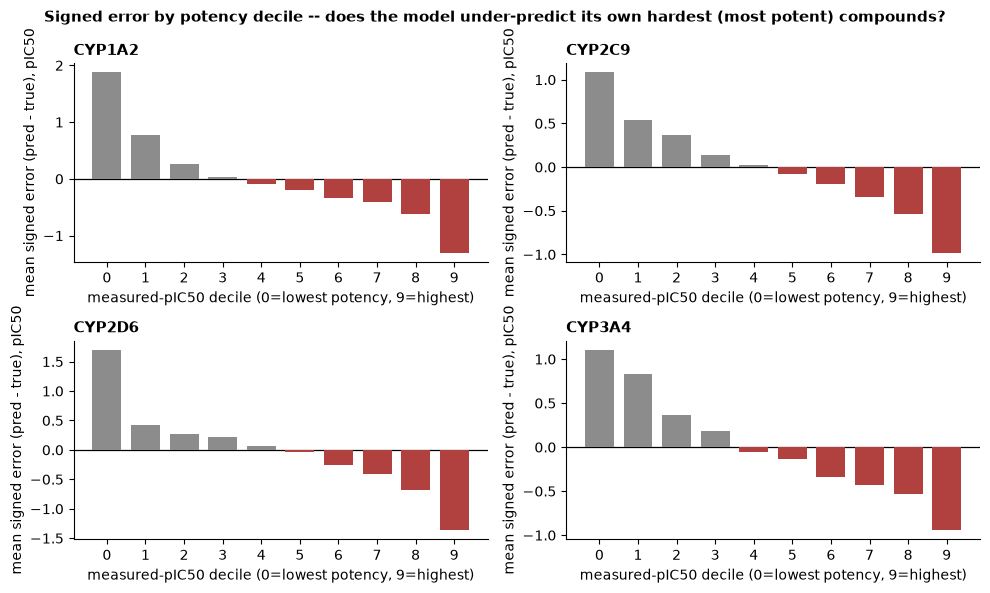

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/26_spread_sweep/figures/signed_error_by_potency_decile.png


In [17]:
# Figure 1 -- signed_error_by_potency_decile.png
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
for ax, iso in zip(axes.flat, ISOFORMS):
    sub = decile_table[decile_table["isoform"] == iso].sort_values("decile")
    colors = [ACCENT_COLOR if v < 0 else BASELINE_COLOR for v in sub["mean_signed_error"]]
    ax.bar(sub["decile"], sub["mean_signed_error"], color=colors, width=0.75)
    ax.axhline(0, color="black", linewidth=0.9, zorder=0)
    ax.set_xlabel("measured-pIC50 decile (0=lowest potency, 9=highest)")
    ax.set_ylabel("mean signed error (pred - true), pIC50")
    ax.set_title(iso, fontsize=11, fontweight="bold", loc="left")
    ax.set_xticks(range(N_DECILES))
    strip_axes(ax)

fig.suptitle("Signed error by potency decile -- does the model under-predict its own hardest (most potent) compounds?",
             fontsize=11, fontweight="bold")
plt.tight_layout()
path1 = FIG_OUT / "signed_error_by_potency_decile.png"
fig.savefig(path1, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {path1}")


**Figure 1. Mean signed error (prediction minus true pIC50) by measured-potency
decile, all compounds, per isoform.** Zero marked by the black baseline; red bars are
negative (under-prediction). **A clean, textbook regression-to-the-mean signature on
all four isoforms, with exactly one sign crossing each**: strongly positive
(over-prediction) at the lowest-potency decile (+1.11 to +1.88 pIC50 units) trending
monotonically to strongly negative (under-prediction) at the highest-potency decile
(-0.95 to -1.37). This is the direct visual evidence behind Part 1's verdict: every
isoform's predictions are compressed toward the mean, and the compounds notebook 25
found hardest — the most potent ones — sit exactly where that compression bites
hardest.


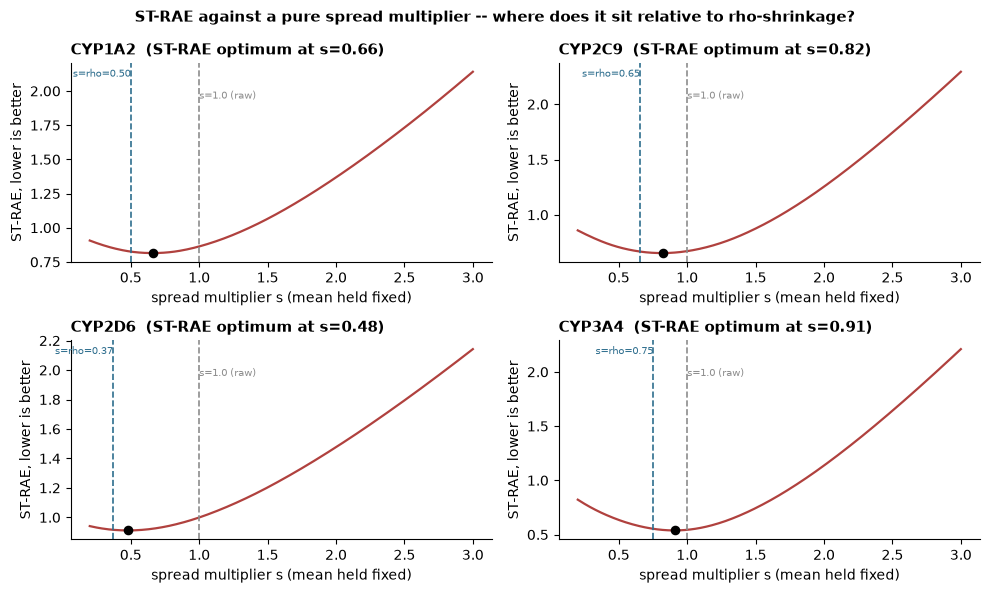

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/26_spread_sweep/figures/strae_vs_spread.png


In [18]:
# Figure 2 -- strae_vs_spread.png
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
for ax, iso in zip(axes.flat, ISOFORMS):
    sub = spread_sweep[spread_sweep["isoform"] == iso]
    opt = spread_optima_df.set_index("isoform").loc[iso]

    ax.plot(sub["s"], sub["strae"], color=ACCENT_COLOR, linewidth=1.6)
    ax.axvline(1.0, color=BASELINE_COLOR, linestyle="--", linewidth=1.2)
    ax.axvline(opt["rho"], color=RHO_COLOR, linestyle="--", linewidth=1.2)
    ax.scatter([opt["strae_optimal_s"]], [opt["strae_at_optimum"]], color="black", s=35, zorder=5)

    ymin, ymax = ax.get_ylim()
    y_span = ymax - ymin
    # rho always sits to the left of s=1.0 in this data -- stagger the two labels at different
    # heights AND anchor them away from each other so they never overlap regardless of gap size.
    ax.text(opt["rho"], ymax - 0.03 * y_span, f"s=rho={opt['rho']:.2f}", color=RHO_COLOR, fontsize=7.5, ha="right", va="top")
    ax.text(1.0, ymax - 0.14 * y_span, "s=1.0 (raw)", color=BASELINE_COLOR, fontsize=7.5, ha="left", va="top")

    ax.set_xlabel("spread multiplier s (mean held fixed)")
    ax.set_ylabel("ST-RAE, lower is better")
    ax.set_title(f"{iso}  (ST-RAE optimum at s={opt['strae_optimal_s']:.2f})", fontsize=10.5, fontweight="bold", loc="left")
    strip_axes(ax)

fig.suptitle("ST-RAE against a pure spread multiplier -- where does it sit relative to rho-shrinkage?",
             fontsize=11, fontweight="bold")
plt.tight_layout()
path2 = FIG_OUT / "strae_vs_spread.png"
fig.savefig(path2, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {path2}")


**Figure 2. OOF ST-RAE against a pure spread multiplier, `chemprop_chemeleoninit`,
per isoform.** Dashed lines mark `s=1.0` (raw, untouched predictions) and `s=rho`
(the shrinkage factor this project's own deployed calibration applies); the black dot
marks the ST-RAE optimum. **A consistent pattern across all four isoforms**: the
ST-RAE optimum sits between rho and 1.0 every time, closer to rho than to raw but
never at it — CYP1A2 s=0.66 vs. rho=0.50, CYP2C9 s=0.82 vs. rho=0.65, CYP2D6 s=0.48
vs. rho=0.37, CYP3A4 s=0.91 vs. rho=0.75 (CYP2C9's rho, flagged in the text above,
comes from a different model than the curve shown here). **Rho-shrinkage — provably
optimal under squared error — over-shrinks relative to what ST-RAE actually wants,
on every isoform, by a strikingly similar margin (~0.11-0.17 s-units)**, though the
resulting ST-RAE cost of using rho instead of the true optimum is small in absolute
terms (0.004-0.015 ST-RAE units) — the same order of magnitude as notebook 21's own
offset-only headroom (0.006-0.022).


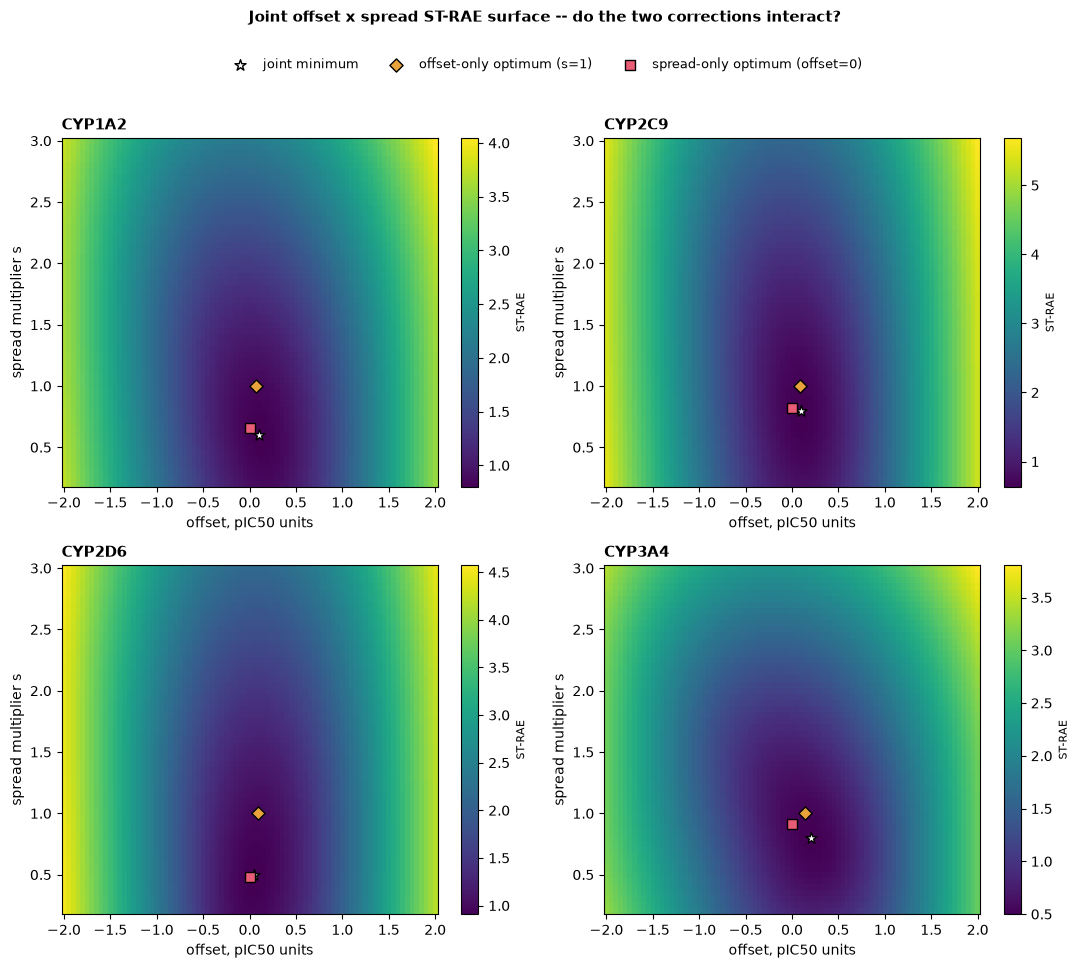

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/26_spread_sweep/figures/joint_offset_spread_surface.png


In [19]:
# Figure 3 -- joint_offset_spread_surface.png
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, iso in zip(axes.flat, ISOFORMS):
    sub = joint_surface[joint_surface["isoform"] == iso]
    pivot = sub.pivot(index="s", columns="offset", values="strae")
    jopt = joint_optima_df.set_index("isoform").loc[iso]

    mesh = ax.pcolormesh(pivot.columns.to_numpy(), pivot.index.to_numpy(), pivot.to_numpy(),
                          shading="auto", cmap="viridis")
    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label("ST-RAE", fontsize=8)

    ax.scatter([jopt["joint_optimal_offset"]], [jopt["joint_optimal_s"]], color="white", edgecolor="black",
               s=70, marker="*", zorder=5, label="joint minimum")
    ax.scatter([jopt["offset_only_optimum"]], [1.0], color="#E8A33D", edgecolor="black",
               s=45, marker="D", zorder=5, label="offset-only optimum (s=1)")
    ax.scatter([0.0], [jopt["s_only_optimum"]], color="#E85D75", edgecolor="black",
               s=45, marker="s", zorder=5, label="spread-only optimum (offset=0)")

    ax.set_xlabel("offset, pIC50 units")
    ax.set_ylabel("spread multiplier s")
    ax.set_title(iso, fontsize=10.5, fontweight="bold", loc="left")

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.03), fontsize=9)
fig.suptitle("Joint offset x spread ST-RAE surface -- do the two corrections interact?", fontsize=11, fontweight="bold", y=1.07)
plt.tight_layout()
path3 = FIG_OUT / "joint_offset_spread_surface.png"
fig.savefig(path3, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {path3}")


**Figure 3. Joint offset x spread OOF ST-RAE surface, per isoform.** The offset-only
optimum (diamond, at `s=1`, from notebook 21) and the spread-only optimum (square, at
`offset=0`, from Figure 2) sit close together but not identically to the true joint
minimum (star) on any isoform. Per this notebook's stated 0.002-ST-RAE-unit
materiality bar, **CYP1A2, CYP2D6 and CYP3A4 show a small but material interaction**
between the two corrections (naive-combination-vs-joint gaps of 0.006, 0.003 and
0.008 ST-RAE units respectively) — applying each one-dimensional optimum
independently leaves a small amount of exploitable ST-RAE on the table relative to
optimising them jointly. **CYP2C9 is the one isoform where the two corrections are
genuinely separable** (gap exactly 0.000 at this grid resolution) — its offset-only
and spread-only optima combine to reach the joint minimum exactly.


## Part 5 — Verdict (report, do not act)

This section is a **report**. It states what was found; it does not build a
submission, apply any correction to blind predictions, modify `src/calibration.py`,
or recommend adoption.


In [20]:
print("=" * 78)
print("VERDICT 1 -- is the hard set systematically under-predicted, and does the")
print("potency-decile trend support the compression mechanism?")
print("=" * 78)
for iso in ISOFORMS:
    hard_row = sign_summary[(sign_summary["isoform"] == iso) & (sign_summary["group"] == "consensus_hard")].iloc[0]
    sub = decile_table[decile_table["isoform"] == iso].sort_values("decile")
    trend_supports = sub.iloc[0]["mean_signed_error"] > 0 and sub.iloc[-1]["mean_signed_error"] < 0
    print(f"\n{iso}: hard-set mean signed error={hard_row['mean_signed_error']:+.4f}, "
          f"frac_negative={hard_row['frac_negative']:.3f}")
    print(f"  decile trend {'SUPPORTS' if trend_supports else 'does NOT support'} the compression mechanism "
          f"(lowest decile {'positive' if sub.iloc[0]['mean_signed_error']>0 else 'negative'}, "
          f"highest decile {'negative' if sub.iloc[-1]['mean_signed_error']<0 else 'positive'})")

print()
print("=" * 78)
print("VERDICT 2 -- does the ST-RAE-optimal spread differ materially from rho, and in which direction?")
print("=" * 78)
for _, row in spread_optima_df.iterrows():
    direction = "WIDER than rho (less shrinkage than deployed)" if row["strae_optimal_s"] > row["rho"] else "NARROWER than rho (more shrinkage than deployed)"
    material = abs(row["gap_strae_units_rho_minus_optimum"]) > 0.002
    print(f"{row['isoform']}: ST-RAE optimum s={row['strae_optimal_s']:.2f} vs. rho={row['rho']:.4f} -- {direction}, "
          f"ST-RAE gap={row['gap_strae_units_rho_minus_optimum']:.4f} ({'material' if material else 'small'})")

print()
print("=" * 78)
print("VERDICT 3 -- are offset and spread separable, or do they interact?")
print("=" * 78)
for _, row in joint_optima_df.iterrows():
    separable = abs(row["gap_naive_minus_joint"]) < 0.002
    print(f"{row['isoform']}: {'SEPARABLE' if separable else 'INTERACTING'} "
          f"(naive-vs-joint gap={row['gap_naive_minus_joint']:.4f} ST-RAE units)")


VERDICT 1 -- is the hard set systematically under-predicted, and does the
potency-decile trend support the compression mechanism?

CYP1A2: hard-set mean signed error=-0.1298, frac_negative=0.641
  decile trend SUPPORTS the compression mechanism (lowest decile positive, highest decile negative)

CYP2C9: hard-set mean signed error=-0.7190, frac_negative=0.860
  decile trend SUPPORTS the compression mechanism (lowest decile positive, highest decile negative)

CYP2D6: hard-set mean signed error=-0.6087, frac_negative=0.767
  decile trend SUPPORTS the compression mechanism (lowest decile positive, highest decile negative)

CYP3A4: hard-set mean signed error=-0.9633, frac_negative=0.927
  decile trend SUPPORTS the compression mechanism (lowest decile positive, highest decile negative)

VERDICT 2 -- does the ST-RAE-optimal spread differ materially from rho, and in which direction?
CYP1A2: ST-RAE optimum s=0.66 vs. rho=0.4989 -- WIDER than rho (less shrinkage than deployed), ST-RAE gap=0.0109 

### What this notebook does NOT do

- No model was trained, retrained, or loaded — no Chemprop, no torch import anywhere
  above.
- No correction was applied to any blind prediction; `src/calibration.py` was read,
  never modified.
- No submission was built, validated, or sent.
- No adoption is recommended for any isoform.

### Stated explicitly, per the task's own closing requirement

Every OOF-derived optimum reported above (Parts 1 and 2, all four isoforms) is a
**hypothesis about the blind optimum, not a measurement of it** — the OOF and blind
populations are known, decisively, to differ for CYP2D6 (notebook 21), and have not
been shown to match for the other three isoforms either. Part 3's CYP2D6
solved-population sweep is a second, independent hypothesis under its own stated
approximations (plain RAE, rank-matched synthetic truth) — not a resolution of the
first, and not a measurement either.
